--- 这是机组的运行数据 ---
   环境温度(°C)  输出功率(MW)
0        15       120
1        20       135
2        25       142
3        30       140
4        35       125
5        40       105
6        45        80




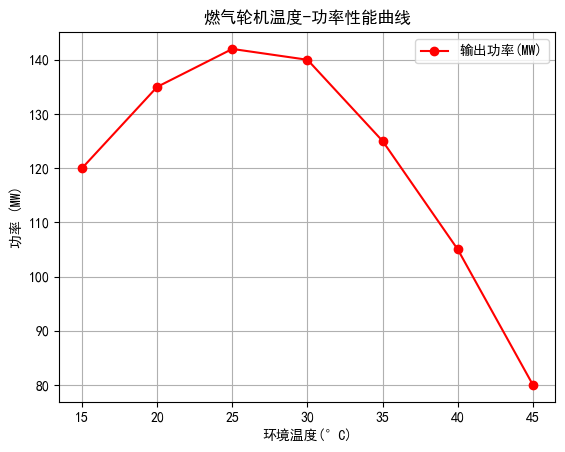

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置字体，防止图表中的中文变成方块
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 模拟您的工程数据
data = {
    '环境温度(°C)': [15, 20, 25, 30, 35, 40, 45],
    '输出功率(MW)': [120, 135, 142, 140, 125, 105, 80]
}

# 2. 将数据转换成 Pandas 的数据表格式
df = pd.DataFrame(data)

print("--- 这是机组的运行数据 ---")
print(df)
print("\n")

# 3. 画出温度与功率的关系曲线图！
df.plot(x='环境温度(°C)', y='输出功率(MW)', kind='line', marker='o', color='red')
plt.title("燃气轮机温度-功率性能曲线")
plt.ylabel("功率 (MW)")
plt.grid(True)
plt.show()


✅ 成功生成并保存 sensor_data.csv 文件！


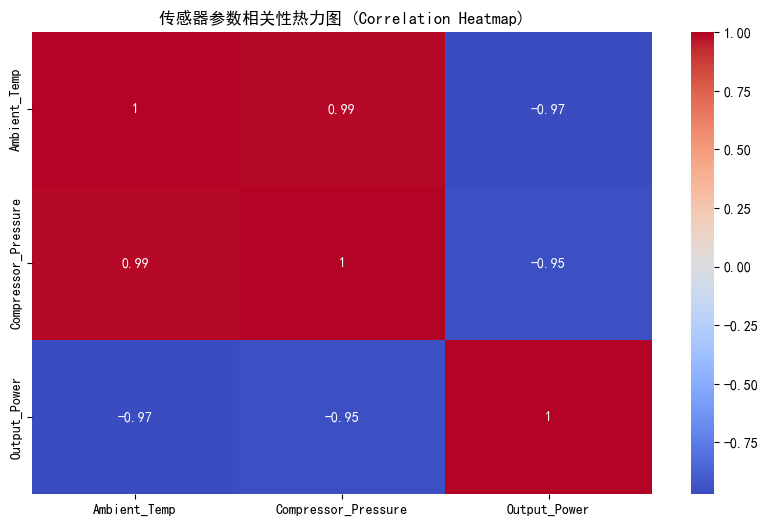

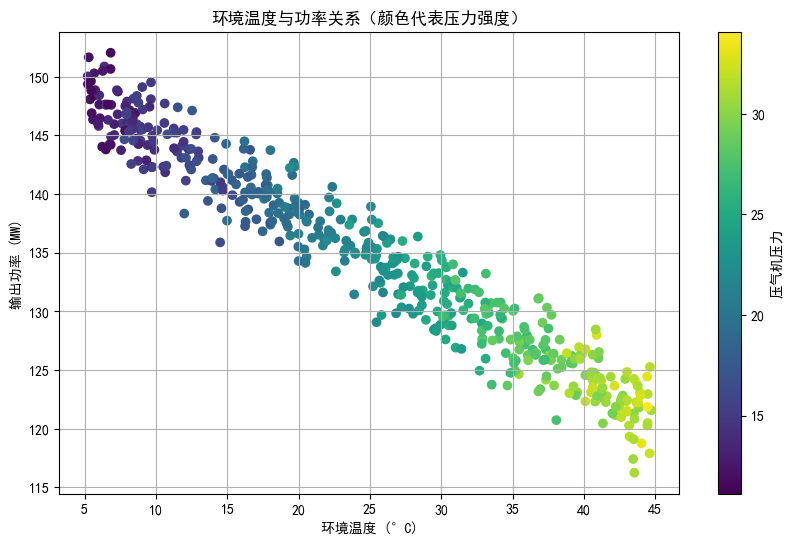

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # 这是一个更高级的画图工具

# 1. 模拟生成 500 组工业传感器数据
np.random.seed(42)
n_samples = 500
temp = np.random.uniform(5, 45, n_samples)  # 环境温度 5-45°C
pressure = 10 + 0.5 * temp + np.random.normal(0, 1, n_samples) # 压气机压力随温度变化
# 输出功率遵循物理规律：随温度升高而下降，随压力升高而上升
power = 150 - 0.8 * temp + 0.2 * pressure + np.random.normal(0, 2, n_samples)

# 故意制造几个“异常值”（模拟传感器故障）
power[10] = 0
power[50] = 300

# 整合进数据表
df = pd.DataFrame({
    'Ambient_Temp': temp,
    'Compressor_Pressure': pressure,
    'Output_Power': power
})

# 2. 数据清洗（展示你的严谨性）
# 剔除明显不合理的功率值（比如小于50或大于250的）
df_clean = df[(df['Output_Power'] > 50) & (df['Output_Power'] < 250)]

# 3. 保存为本地 CSV 文件（这就是你的“实验室数据”）
df_clean.to_csv('sensor_data.csv', index=False)
print("✅ 成功生成并保存 sensor_data.csv 文件！")

# 4. 深度可视化：相关性分析
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("传感器参数相关性热力图 (Correlation Heatmap)")
plt.show()

# 5. 多维度散点图
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Ambient_Temp'], df_clean['Output_Power'], c=df_clean['Compressor_Pressure'], cmap='viridis')
plt.colorbar(label='压气机压力')
plt.xlabel('环境温度 (°C)')
plt.ylabel('输出功率 (MW)')
plt.title('环境温度与功率关系（颜色代表压力强度）')
plt.grid(True)
plt.savefig('performance_chart.png') # 保存这张图，待会要贴到 GitHub 封面上
plt.show()

In [3]:
# --- 进阶：机器学习与预测性建模 (Predictive Modeling) ---
# 引入机器学习界大名鼎鼎的 Scikit-Learn 库
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd

print("🚀 正在启动机器学习引擎...\n")

# 1. 准备AI的“复习资料”
# 特征 (X)：告诉AI输入条件（环境温度、压气机压力）
# 目标 (y)：要求AI预测的结果（输出功率）
X = df_clean[['Ambient_Temp', 'Compressor_Pressure']]
y = df_clean['Output_Power']

# 2. 划分训练集和测试集（80%的数据给AI学习，留20%的数据用来“考试”测验它的水平）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 召唤 AI 算法：随机森林回归器 (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("🧠 AI 正在根据热力学数据拼命学习中...")
model.fit(X_train, y_train) # 让模型开始学习

# 4. 让 AI 参加考试，看看它预测得准不准
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)
print(f"✅ 模型训练完成！平均预测误差仅为: {error:.2f} MW\n")

# 5. 实战演练：预测“明天”的发电量！
# 假设气象局预报明天突发高温：温度 38°C，系统压力预估 28
tomorrow_data = pd.DataFrame({'Ambient_Temp': [38], 'Compressor_Pressure': [28]})
predicted_power = model.predict(tomorrow_data)

print("🔮 【调度中心预警预测】")
print(f"如果明天环境温度达到 38°C，预测该机组的输出功率将降至: {predicted_power[0]:.2f} MW")

🚀 正在启动机器学习引擎...

🧠 AI 正在根据热力学数据拼命学习中...
✅ 模型训练完成！平均预测误差仅为: 1.67 MW

🔮 【调度中心预警预测】
如果明天环境温度达到 38°C，预测该机组的输出功率将降至: 124.86 MW
